<a href="https://colab.research.google.com/github/Caosbot/Treinos_Python/blob/Machine_Learning/Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Inserção dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_gym = pd.read_csv(r"F:\Cursos\DNC\Banco de dados\gym_members_exercise_tracking.csv") #Musicas dos anos 2000

In [3]:
df_gym.shape

(973, 15)

In [4]:
df_gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Analisando dados

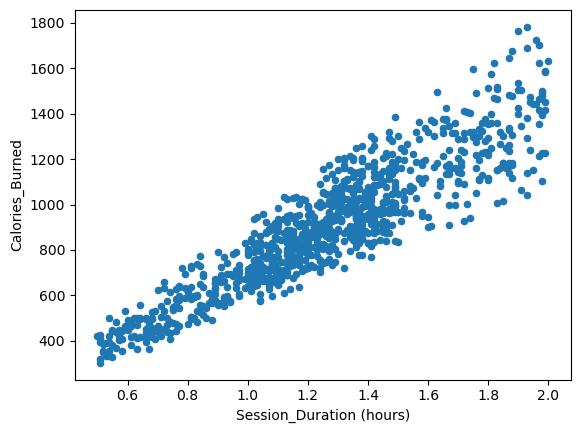

In [5]:
df_gym.plot(x='Session_Duration (hours)', y ='Calories_Burned', kind='scatter' );

In [6]:
X = df_gym[['Session_Duration (hours)']]
y = df_gym[['Calories_Burned']]

## Preparando modelo

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [9]:
pred = model.predict(X)

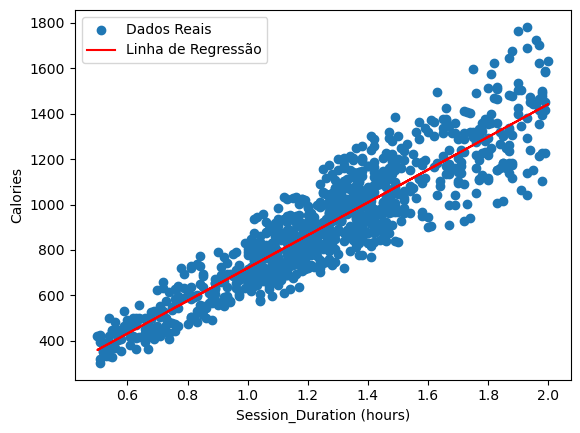

In [10]:
plt.scatter(x=X['Session_Duration (hours)'], y=y, label="Dados Reais")
plt.plot(X['Session_Duration (hours)'], pred, label="Linha de Regressão", color='red')

plt.ylabel("Calories")
plt.xlabel('Session_Duration (hours)')

plt.legend()
plt.show()

In [11]:
residuals = y- pred
residuals

,Calories_Burned
0,94.628092
1,-53.875362
2,-122.736019
3,107.592709
4,95.503409
...,...
968,232.242414
969,265.381757
970,-311.025489
971,90.481841


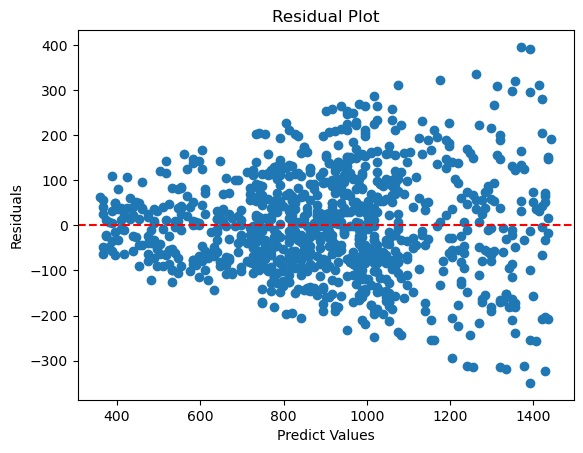

In [12]:
plt.scatter(pred, residuals, label="Dados Reais")
plt.axhline(y=0, color='red', linestyle='--')
#plt.plot(X['Session_Duration (hours)'], pred, label="Linha de Regressão", color='red')

plt.xlabel("Predict Values")
plt.ylabel('Residuals')
plt.title("Residual Plot")

#plt.legend()
plt.show()

Text(0.5, 1.0, 'Pred x Target')

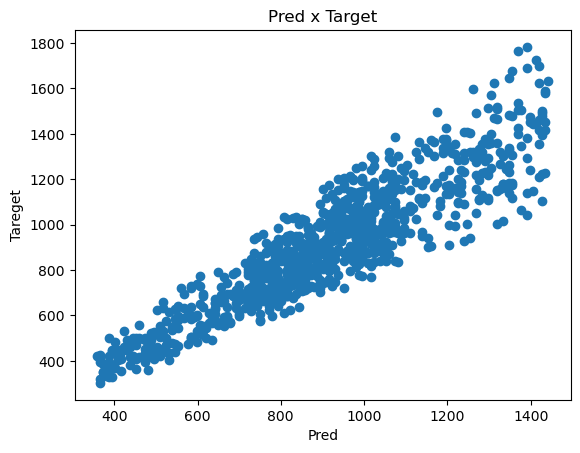

In [13]:
plt.scatter(pred, y)

plt.xlabel("Pred")
plt.ylabel('Tareget')

plt.title("Pred x Target")

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = df_gym.drop('Calories_Burned', axis=1) #Drop na coluna
y = df_gym['Calories_Burned']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.20)

In [17]:
X_train.shape, X_test.shape

((778, 14), (195, 14))

In [18]:
X_train.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
967,20,Male,55.0,1.60,172,168,67,1.12,Yoga,24.0,3.2,4,2,21.48
365,39,Female,60.6,1.65,162,167,63,0.92,HIIT,27.6,1.7,3,1,22.26
559,54,Female,75.6,1.72,194,154,60,0.97,Cardio,26.4,1.9,3,1,25.55
33,24,Female,58.9,1.51,187,157,68,1.04,Cardio,31.7,2.5,2,1,25.83
31,20,Female,65.4,1.52,185,127,50,1.03,Yoga,28.0,2.2,4,2,28.31


One-Hot-Encoder: Transforma variáveis categóricas em um formato lido por algoritmos de machine learning

In [19]:
X_train['Workout_Type'].nunique()

4

In [20]:
X_train['Workout_Type'].value_counts()

Workout_Type
Strength    211
Cardio      209
Yoga        179
HIIT        179
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoder.fit(X_train[['Workout_Type', 'Gender']])

X_train_categorical_columns = encoder.transform(X_train[['Workout_Type', 'Gender']])
X_test_categorical_columns = encoder.transform(X_test[['Workout_Type', 'Gender']])

In [23]:
X_train = pd.concat(
    [X_train.drop(['Workout_Type', 'Gender'], axis=1),
     X_train_categorical_columns], axis=1) #Drop nas colunas categoricas str e adiciona as categoricas onehot

In [24]:
X_test = pd.concat(
    [X_test.drop(['Workout_Type', 'Gender'], axis=1),
     X_test_categorical_columns], axis=1) #Drop nas colunas categoricas str e adiciona as categoricas onehot

Agora X_train e X_test tem apenas colunas numéricas

In [25]:
X_train.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Gender_Female,Gender_Male
967,20,55.0,1.60,172,168,67,1.12,24.0,3.2,4,2,21.48,0.0,0.0,0.0,1.0,0.0,1.0
365,39,60.6,1.65,162,167,63,0.92,27.6,1.7,3,1,22.26,0.0,1.0,0.0,0.0,1.0,0.0
559,54,75.6,1.72,194,154,60,0.97,26.4,1.9,3,1,25.55,1.0,0.0,0.0,0.0,1.0,0.0
33,24,58.9,1.51,187,157,68,1.04,31.7,2.5,2,1,25.83,1.0,0.0,0.0,0.0,1.0,0.0
31,20,65.4,1.52,185,127,50,1.03,28.0,2.2,4,2,28.31,0.0,0.0,0.0,1.0,1.0,0.0


In [26]:
X_train['Session_Duration (hours)']

967    1.12
365    0.92
559    0.97
33     1.04
31     1.03
       ... 
106    0.51
270    1.40
860    1.38
435    1.43
102    1.20
Name: Session_Duration (hours), Length: 778, dtype: float64

In [27]:
model = LinearRegression()
model.fit(X_train[['Session_Duration (hours)']], y_train)

y_pred = model.predict(X_test[['Session_Duration (hours)']])

In [28]:
residuals = y_test - y_pred

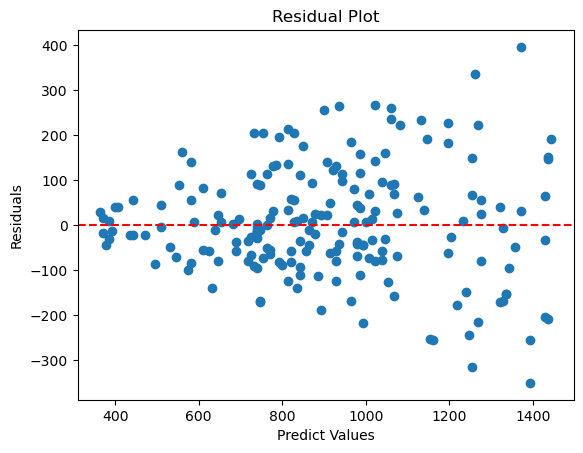

In [29]:
plt.scatter(y_pred, residuals, label="Dados Reais")
plt.axhline(y=0, color='red', linestyle='--')


plt.xlabel("Predict Values")
plt.ylabel('Residuals')
plt.title("Residual Plot")

plt.show()

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [31]:
residuals = y_test - y_pred

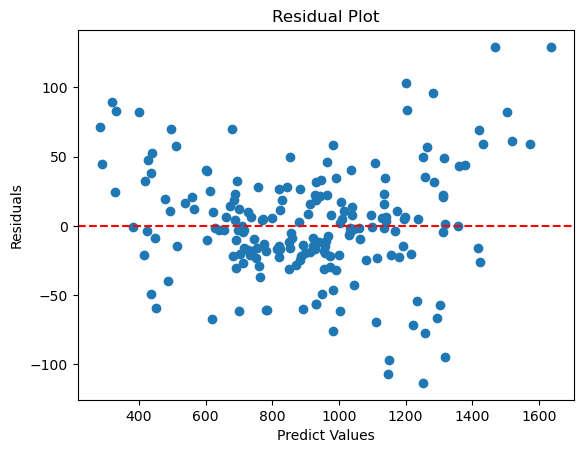

In [32]:
plt.scatter(y_pred, residuals, label="Dados Reais")
plt.axhline(y=0, color='red', linestyle='--')


plt.xlabel("Predict Values")
plt.ylabel('Residuals')
plt.title("Residual Plot")

plt.show()

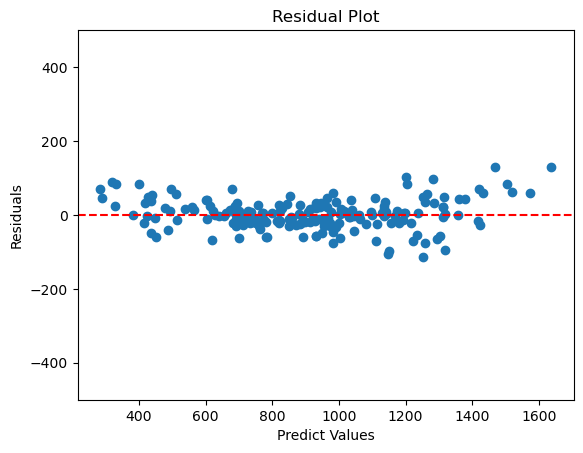

In [33]:
plt.scatter(y_pred, residuals, label="Dados Reais")
plt.axhline(y=0, color='red', linestyle='--')


plt.xlabel("Predict Values")
plt.ylabel('Residuals')
plt.title("Residual Plot")
plt.ylim(-500,500)

plt.show()

## Interpretando Coeficientes

ŷ = β₀ + β₁X₁ + β₂X₂ + ... β*nX*n

### Calculando manualmente

In [34]:
model.intercept_

-983.6778704343158

In [35]:
model.coef_

array([-3.31556080e+00, -1.00598336e+00,  1.08168013e+02,  1.08805915e-01,
        6.15788095e+00,  6.03315684e-01,  7.12813300e+02, -6.43730698e-01,
       -3.53909166e+00,  3.95769050e+00, -3.67455298e+00,  3.36018705e+00,
        3.95997991e+00, -2.67674260e-01,  6.95260162e-01, -4.38756581e+00,
       -4.12986606e+01,  4.12986606e+01])

In [36]:
print(f"{len(model.coef_)}, {X_train.shape}")

18, (778, 18)


In [37]:
X_train.iloc[0]

Age                               20.00
Weight (kg)                       55.00
Height (m)                         1.60
Max_BPM                          172.00
Avg_BPM                          168.00
Resting_BPM                       67.00
Session_Duration (hours)           1.12
Fat_Percentage                    24.00
Water_Intake (liters)              3.20
Workout_Frequency (days/week)      4.00
Experience_Level                   2.00
BMI                               21.48
Workout_Type_Cardio                0.00
Workout_Type_HIIT                  0.00
Workout_Type_Strength              0.00
Workout_Type_Yoga                  1.00
Gender_Female                      0.00
Gender_Male                        1.00
Name: 967, dtype: float64

In [38]:
X_test.iloc[0].values

array([ 34.  ,  71.9 ,   1.64, 170.  , 134.  ,  67.  ,   1.26,  21.3 ,
         2.1 ,   4.  ,   2.  ,  26.73,   1.  ,   0.  ,   0.  ,   0.  ,
         0.  ,   1.  ])

In [39]:
x =X_test.iloc[0].values

In [40]:
sum(model.coef_ * x) + model.intercept_

913.2929019751894

### Verificando na saída do modelo

In [41]:
y_pred[0]

913.2929019751894

## Analise

In [42]:
import seaborn as sns

In [43]:
df_coef =pd.DataFrame({
    "Features": X_train.columns,
    "Coeficientes": model.coef_
})
df_coef

,Features,Coeficientes
0,Age,-3.315561
1,Weight (kg),-1.005983
2,Height (m),108.168013
3,Max_BPM,0.108806
4,Avg_BPM,6.157881
5,Resting_BPM,0.603316
6,Session_Duration (hours),712.813300
7,Fat_Percentage,-0.643731
8,Water_Intake (liters),-3.539092
9,Workout_Frequency (days/week),3.957690


In [44]:
df_coef['Coeficientes_Absoluto'] = df_coef['Coeficientes'].abs()

In [45]:
df_coef

,Features,Coeficientes,Coeficientes_Absoluto
0,Age,-3.315561,3.315561
1,Weight (kg),-1.005983,1.005983
2,Height (m),108.168013,108.168013
3,Max_BPM,0.108806,0.108806
4,Avg_BPM,6.157881,6.157881
5,Resting_BPM,0.603316,0.603316
6,Session_Duration (hours),712.813300,712.813300
7,Fat_Percentage,-0.643731,0.643731
8,Water_Intake (liters),-3.539092,3.539092
9,Workout_Frequency (days/week),3.957690,3.957690


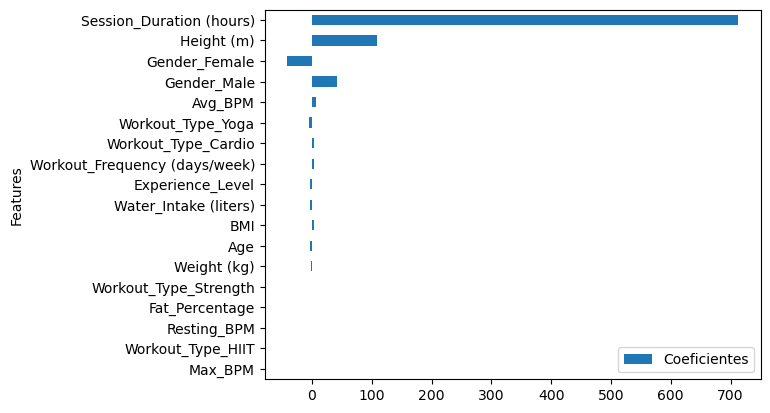

In [46]:
df_coef.sort_values("Coeficientes_Absoluto", ascending=True).plot(kind='barh',x='Features', y='Coeficientes' );

In [47]:
y

0      1313.0
1       883.0
2       677.0
3       532.0
4       556.0
        ...  
968    1364.0
969    1260.0
970     929.0
971     883.0
972     542.0
Name: Calories_Burned, Length: 973, dtype: float64

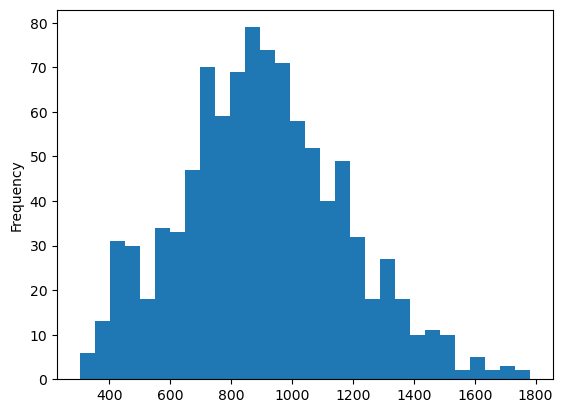

In [48]:
y.plot(kind='hist', bins=30);

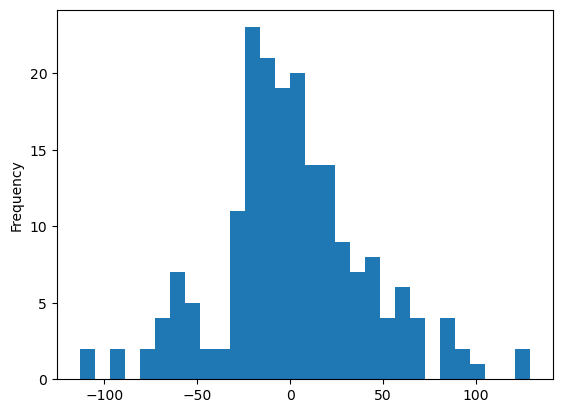

In [49]:
residuals.plot(kind='hist', bins=30);

In [50]:
df_corr =X_train.corr(numeric_only=True)
df_corr

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Gender_Female,Gender_Male
Age,1.000000,-0.067671,-0.016373,-0.021903,0.080135,-0.008126,-0.011484,0.008664,0.034919,0.030417,-0.008071,-0.053464,-0.040301,0.003777,0.019944,0.017598,-0.006300,0.006300
Weight (kg),-0.067671,1.000000,0.372351,0.049328,-0.011073,-0.013469,-0.011101,-0.234515,0.408174,0.005948,0.015118,0.849798,0.026978,0.039012,-0.046924,-0.017857,-0.573180,0.573180
Height (m),-0.016373,0.372351,1.000000,-0.057417,-0.017122,-0.000547,-0.009226,-0.238102,0.391995,0.001349,0.004269,-0.157753,-0.019376,-0.013922,-0.025376,0.061132,-0.586690,0.586690
Max_BPM,-0.021903,0.049328,-0.057417,1.000000,-0.042396,0.027311,0.030093,-0.013544,0.030548,-0.021016,0.000106,0.083389,0.008156,0.012005,-0.041880,0.023644,0.011065,-0.011065
Avg_BPM,0.080135,-0.011073,-0.017122,-0.042396,1.000000,0.070027,0.028216,-0.020048,-0.003184,-0.001472,0.009077,-0.002203,0.000443,-0.005342,0.009270,-0.004917,-0.000266,0.000266
Resting_BPM,-0.008126,-0.013469,-0.000547,0.027311,0.070027,1.000000,0.023454,-0.031448,0.053768,0.020149,0.031435,-0.013961,-0.050151,0.057657,0.031273,-0.037874,-0.021415,0.021415
Session_Duration (hours),-0.011484,-0.011101,-0.009226,0.030093,0.028216,0.023454,1.000000,-0.578470,0.254766,0.639245,0.763745,-0.003247,-0.051015,0.048021,0.014462,-0.009571,0.028182,-0.028182
Fat_Percentage,0.008664,-0.234515,-0.238102,-0.013544,-0.020048,-0.031448,-0.578470,1.000000,-0.586133,-0.536769,-0.652545,-0.125843,0.043005,-0.061803,0.052382,-0.038819,0.406813,-0.406813
Water_Intake (liters),0.034919,0.408174,0.391995,0.030548,-0.003184,0.053768,0.254766,-0.586133,1.000000,0.233791,0.289955,0.229339,-0.003511,0.058777,-0.042847,-0.009819,-0.673774,0.673774
Workout_Frequency (days/week),0.030417,0.005948,0.001349,-0.021016,-0.001472,0.020149,0.639245,-0.536769,0.233791,1.000000,0.831661,0.013200,-0.059923,0.014981,0.037810,0.008187,0.002357,-0.002357


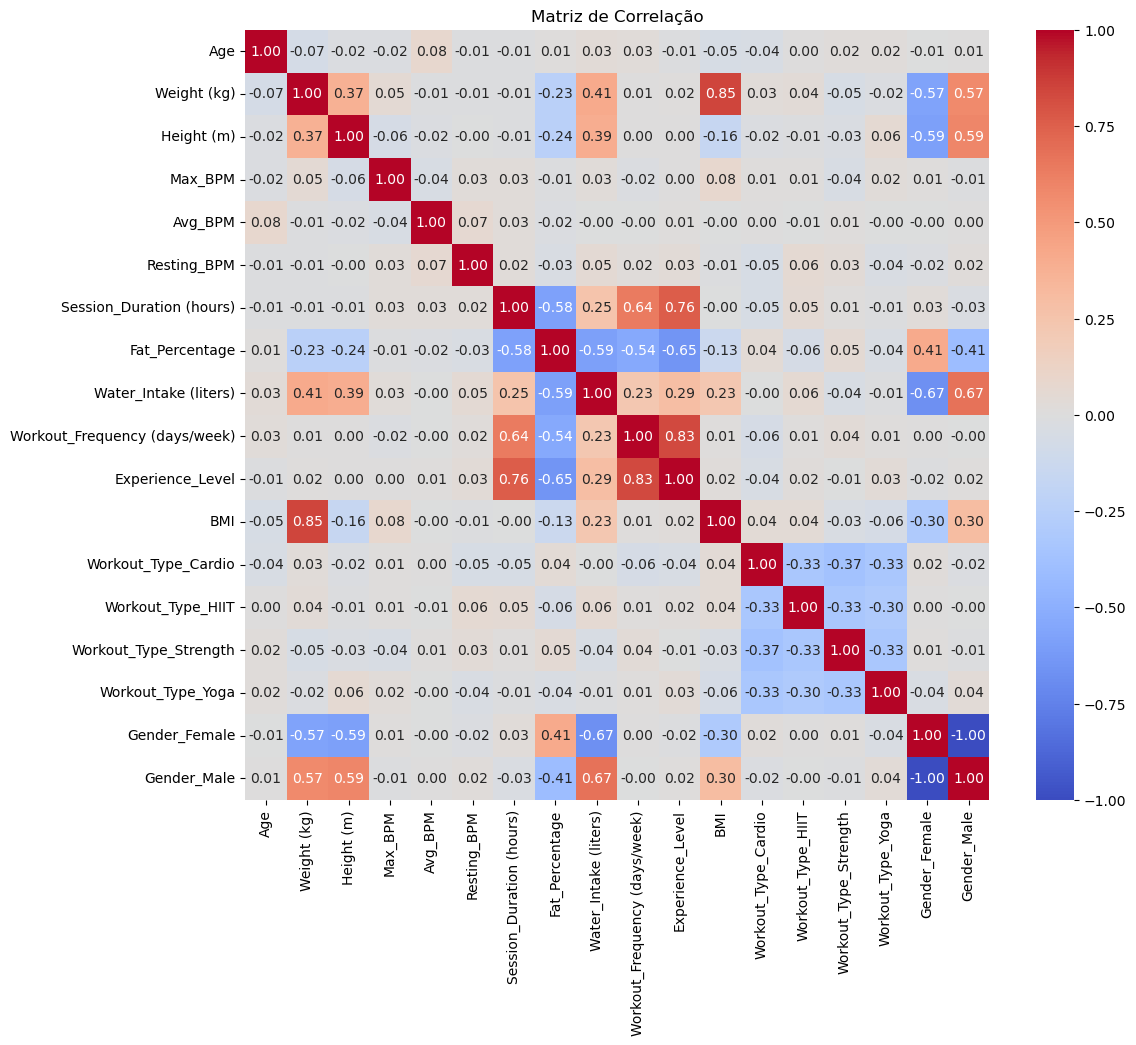

In [51]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

## Métodos de Avaliação

### Métrica - MAE

In [52]:
residuals.abs().mean() #erro médio de calorias

30.270139845321

In [53]:
from sklearn.metrics import mean_absolute_error

In [54]:
mean_absolute_error(y_test, y_pred)

30.270139845321

In [55]:
model = LinearRegression()
model.fit(X_train[['Session_Duration (hours)']], y_train)

y_pred = model.predict(X_test[['Session_Duration (hours)']])
mae = mean_absolute_error(y_test, y_pred)
mae

95.03480033445553

In [56]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae

30.270139845321

### Métricas - MSE e RMSE

In [57]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [58]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

In [59]:
print(f"MSE: {mse}\nRMSE: {rmse}")

MSE: 1646.176014597071
RMSE: 40.57309471308629


In [60]:
np.sqrt(mse)

40.57309471308629

In [61]:
(residuals ** 2).mean()

1646.176014597071

### Métrica MAPE

In [62]:
from sklearn.metrics import mean_absolute_percentage_error

In [65]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape*100:.2f}%")

MAPE: 3.69%


### Métrica R2

In [66]:
from sklearn.metrics import r2_score

In [68]:
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2}")

R2: 0.9802675995368525
